<a href="https://colab.research.google.com/github/estevesleo/SimuladorUGS/blob/main/SimuladorUGS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%%writefile simulador_ugs.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <iomanip>
#include <fstream>
#include <string>
#include <cstdio>

using namespace std;

// ======================================================
// ESTRUTURAS BÁSICAS
// ======================================================

struct Parametros {
    int nx, nz;
    double Lx, Lz, h;
    double dx, dz;

    double dt;
    double tmax;
    double tempoAtual;

    double phi_ref;
    double kx_ref;
    double kz_ref;

    int iInj, kInj;   //Posição do poço injetor
    int iProd, kProd; // Posição do poço produtor
    double WI_inj;    // Indice
    double WI_prod;
    double pInj;     //Pressao-alvo
    double pProd;



    double p_init;
    double p_ref;
    double D_ref;

    double muw;
    double mug;

    double Bw0;
    double cw;

    double Sgc;
    double Swr;

    double rho_w;
    double rho_g;
    double g;

    double Hs;     // constante de Henry simplificada
    double Dh;     // difusão/dispersão hidrodinâmica simplificada
    double km;     // coef. cinético simplificado

    double dtBase;
    double cflSafety;

    double tolPicard;
    double tolGS;
    int maxPicard;
    int maxGS;
};

struct Scheduler {
    double tInjecao;
    double tRepouso;
    double tProducao;

    double qInjGas;
    double qProdGas;
};

struct Campos {
    vector<double> p;
    vector<double> p_old;

    vector<double> Sg;
    vector<double> Sg_old;
    vector<double> Sw;

    vector<double> C;
    vector<double> C_old;

    vector<double> phi;
    vector<double> kx;
    vector<double> kz;
    vector<double> depth;
};

struct EstadoOperacional {
    string modo; // "injecao", "repouso", "producao"
    double qGas;
};
struct CasoEstudo {
    string nome;
    bool usarGravidade;
    bool usarDissolucao;
};
struct ResumoCaso {
    string nome;

    double tempoFinal;
    double dtFinal;

    double erroPFinal;

    double pMed;
    double pMin;
    double pMax;

    double sgMed;
    double sgMin;
    double sgMax;

    double cMed;
    double cMin;
    double cMax;

    double massaLivre;
    double massaDissolvida;

    double pInjCell;
    double pProdCell;

    double sgInjCell;
    double sgProdCell;
};
// ======================================================
// FUNÇÕES AUXILIARES
// ======================================================

int idx(int i, int k, int nx) {
    return k * nx + i;
}

double clamp(double x, double xmin, double xmax) {
    if (x < xmin) return xmin;
    if (x > xmax) return xmax;
    return x;
}

// ======================================================
// PROPRIEDADES FÍSICAS
// ======================================================

double Bw(double p, const Parametros& par) {
    return par.Bw0 / (1.0 + par.cw * (p - par.p_ref));
}

double Bg(double p) {
    // versão simplificada inicial
    // depois podemos colocar Z(p,T)
    return 1.0 / max(p, 1.0);
}

double krg(double Sg, const Parametros& par) {
    double denom = 1.0 - par.Swr - par.Sgc;
    double Se = (Sg - par.Sgc) / denom;
    Se = clamp(Se, 0.0, 1.0);
    return Se * Se;
}

double krw(double Sg, const Parametros& par) {
    double Sw = 1.0 - Sg;
    double denom = 1.0 - par.Swr - par.Sgc;
    double Se = (Sw - par.Swr) / denom;
    Se = clamp(Se, 0.0, 1.0);
    return Se * Se;
}

double lambda_w(double Sg, double p, const Parametros& par) {
    return krw(Sg, par) / (par.muw * Bw(p, par));
}

double lambda_g(double Sg, double p, const Parametros& par) {
    return krg(Sg, par) / (par.mug * Bg(p));
}

// ======================================================
// INICIALIZAÇÃO
// ======================================================

void inicializarParametros(Parametros& par) {
    par.nx = 40;
    par.nz = 12;

    par.Lx = 1000.0;
    par.Lz = 120.0;
    par.h  = 1.0;

    par.dx = par.Lx / par.nx;
    par.dz = par.Lz / par.nz;

    par.dtBase = 0.02;
    par.dt = par.dtBase;
    par.cflSafety = 0.5;
    par.tmax = 200.0;
    par.tempoAtual = 0.0;

    par.phi_ref = 0.20;
    par.kx_ref = 0.15;
    par.kz_ref = 0.05;

    par.p_init = 10000.0;
    par.p_ref  = 10000.0;
    par.D_ref  = 1000.0;

    par.muw = 1.0;
    par.mug = 0.05;

    par.Bw0 = 1.0;
    par.cw  = 1.0e-6;

    par.Sgc = 0.05;
    par.Swr = 0.10;

    par.rho_w = 1000.0;
    par.rho_g = 120.0;
    par.g = 9.81;

    par.Hs = 1.0e-5;
    par.Dh = 0.02;
    par.km = 0.05;

    par.tolPicard = 1.0e-6;
    par.tolGS = 1.0e-8;
    par.maxPicard = 30;
    par.maxGS = 5000;

    par.iInj = par.nx / 4;
    par.kInj = par.nz / 2;

    par.iProd = 3 * par.nx / 4;
    par.kProd = par.nz / 2;

    par.WI_inj = 5.0;
    par.WI_prod = 5.0;

    par.pInj = 12000.0;
    par.pProd = 8000.0;
}

void inicializarScheduler(Scheduler& sch) {
    sch.tInjecao = 40.0;
    sch.tRepouso = 20.0;
    sch.tProducao = 40.0;

    sch.qInjGas = 1.0;
    sch.qProdGas = -1.0;
}

void alocarCampos(Campos& c, const Parametros& par) {
    int N = par.nx * par.nz;

    c.p.assign(N, 0.0);
    c.p_old.assign(N, 0.0);

    c.Sg.assign(N, 0.0);
    c.Sg_old.assign(N, 0.0);
    c.Sw.assign(N, 1.0);

    c.C.assign(N, 0.0);
    c.C_old.assign(N, 0.0);

    c.phi.assign(N, 0.0);
    c.kx.assign(N, 0.0);
    c.kz.assign(N, 0.0);
    c.depth.assign(N, 0.0);
}

void inicializarCampos(Campos& c, const Parametros& par) {
    for (int k = 0; k < par.nz; k++) {
        for (int i = 0; i < par.nx; i++) {
            int id = idx(i, k, par.nx);

            double z = (k + 0.5) * par.dz;
            c.depth[id] = par.D_ref + z;

            c.p[id] = par.p_init + par.rho_w * par.g * (c.depth[id] - par.D_ref) / 1000.0;
            c.p_old[id] = c.p[id];

            c.Sg[id] = 0.0;
            c.Sg_old[id] = 0.0;
            c.Sw[id] = 1.0;

            c.C[id] = 0.0;
            c.C_old[id] = 0.0;

            c.phi[id] = par.phi_ref;

            // heterogeneidade simples inicial
            double fatorH = 1.0 + 0.30 * sin(2.0 * M_PI * i / par.nx) * cos(2.0 * M_PI * k / par.nz);
            c.kx[id] = par.kx_ref * fatorH;
            c.kz[id] = par.kz_ref * fatorH;
        }
    }
}

// ======================================================
// SCHEDULER
// ======================================================

EstadoOperacional obterEstadoOperacional(double tempo, const Scheduler& sch) {
    EstadoOperacional est;
    double periodo = sch.tInjecao + sch.tRepouso + sch.tProducao;
    double fase = fmod(tempo, periodo);

    if (fase < sch.tInjecao) {
        est.modo = "injecao";
        est.qGas = sch.qInjGas;
    } else if (fase < sch.tInjecao + sch.tRepouso) {
        est.modo = "repouso";
        est.qGas = 0.0;
    } else {
        est.modo = "producao";
        est.qGas = sch.qProdGas;
    }
    return est;
}

// ======================================================
// TRANSMISSIBILIDADES
// ======================================================

double mediaHarmonica(double a, double b) {
    if (a <= 0.0 || b <= 0.0) return 0.0;
    return 2.0 * a * b / (a + b);
}

// ======================================================
// SOLVER DE PRESSÃO (BASE PROFISSIONAL INICIAL)
// ======================================================

void copiarPressaoAntiga(Campos& c) {
    c.p_old = c.p;
}
bool ehPocoInjetor(int i, int k, const Parametros& par) {
    return (i == par.iInj && k == par.kInj);
}

bool ehPocoProdutor(int i, int k, const Parametros& par) {
    return (i == par.iProd && k == par.kProd);
}
double resolverPressaoPicardGS(Campos& c, const Parametros& par, const EstadoOperacional& est, const CasoEstudo& caso) {
    double erroPicard = 0.0;

    for (int itPic = 0; itPic < par.maxPicard; itPic++) {
        vector<double> p_prev = c.p;

        for (int itGS = 0; itGS < par.maxGS; itGS++) {
            double erroGS = 0.0;

            for (int k = 0; k < par.nz; k++) {
                for (int i = 0; i < par.nx; i++) {
                    int id = idx(i, k, par.nx);

                    double ap = 0.0;
                    double soma = 0.0;

                    double lambdat = lambda_w(c.Sg[id], c.p[id], par)
                                   + lambda_g(c.Sg[id], c.p[id], par);

                    // Oeste
                    if (i > 0) {
                        int iw = idx(i - 1, k, par.nx);
                        double kface = mediaHarmonica(c.kx[id], c.kx[iw]);
                        double Tx = kface * lambdat * (par.dz * par.h) / par.dx;
                        ap += Tx;
                        soma += Tx * c.p[iw];
                    }

                    // Leste
                    if (i < par.nx - 1) {
                        int ie = idx(i + 1, k, par.nx);
                        double kface = mediaHarmonica(c.kx[id], c.kx[ie]);
                        double Tx = kface * lambdat * (par.dz * par.h) / par.dx;
                        ap += Tx;
                        soma += Tx * c.p[ie];
                    }

                    // Sul
                    if (k > 0) {
                        int is = idx(i, k - 1, par.nx);
                        double kface = mediaHarmonica(c.kz[id], c.kz[is]);
                        double Tz = kface * lambdat * (par.dx * par.h) / par.dz;
                        ap += Tz;
                        soma += Tz * c.p[is];
                    }

                    // Norte
                    if (k < par.nz - 1) {
                        int in = idx(i, k + 1, par.nx);
                        double kface = mediaHarmonica(c.kz[id], c.kz[in]);
                        double Tz = kface * lambdat * (par.dx * par.h) / par.dz;
                        ap += Tz;
                        soma += Tz * c.p[in];
                    }

                    // Acúmulo implícito da pressão
                    double Vb = par.dx * par.dz * par.h;
                    double acum = c.phi[id] * Vb / par.dt;
                    ap += acum;

                    double fonte = acum * c.p_old[id];

                    // Poços
                    bool pocoInj = ehPocoInjetor(i, k, par);
                    bool pocoProd = ehPocoProdutor(i, k, par);

                    if (est.modo == "injecao" && pocoInj) {
                        ap += par.WI_inj;
                        fonte += par.WI_inj * par.pInj;
                    }

                    if (est.modo == "producao" && pocoProd) {
                        ap += par.WI_prod;
                        fonte += par.WI_prod * par.pProd;
                    }

                    double pNovo = (soma + fonte) / ap;

                    erroGS = max(erroGS, fabs(pNovo - c.p[id]));
                    c.p[id] = pNovo;
                }
            }

            if (erroGS < par.tolGS) break;
        }

        erroPicard = 0.0;
        for (size_t n = 0; n < c.p.size(); n++) {
            erroPicard = max(erroPicard, fabs(c.p[n] - p_prev[n]));
        }

        if (erroPicard < par.tolPicard) break;
    }

    return erroPicard;
}

// ======================================================
// ATUALIZAÇÃO EXPLÍCITA DA SATURAÇÃO
// ======================================================

void copiarSaturacaoAntiga(Campos& c) {
    c.Sg_old = c.Sg;
}
double potencialGas(double p, double depth, const Parametros& par, bool usarGravidade) {
    if (!usarGravidade) return p;
    return p - par.rho_g * par.g * depth / 1000.0;
}

double potencialAgua(double p, double depth, const Parametros& par, bool usarGravidade) {
    if (!usarGravidade) return p;
    return p - par.rho_w * par.g * depth / 1000.0;
}

double transmissibilidadeGasX(int id1, int id2, const Campos& c, const Parametros& par, bool usarGravidade) {
    double kface = mediaHarmonica(c.kx[id1], c.kx[id2]);

    double phi1 = potencialGas(c.p[id1], c.depth[id1], par, usarGravidade);
    double phi2 = potencialGas(c.p[id2], c.depth[id2], par, usarGravidade);
    int up = (phi1 >= phi2) ? id1 : id2;

    double lambdag = lambda_g(c.Sg[up], c.p[up], par);

    return kface * lambdag * (par.dz * par.h) / par.dx;
}

double transmissibilidadeGasZ(int id1, int id2, const Campos& c, const Parametros& par, bool usarGravidade) {
    double kface = mediaHarmonica(c.kz[id1], c.kz[id2]);

    double phi1 = potencialGas(c.p[id1], c.depth[id1], par, usarGravidade);
    double phi2 = potencialGas(c.p[id2], c.depth[id2], par, usarGravidade);

    int up = (phi1 >= phi2) ? id1 : id2;

    double lambdag = lambda_g(c.Sg[up], c.p[up], par);

    return kface * lambdag * (par.dx * par.h) / par.dz;
}
double transmissibilidadeAguaX(int id1, int id2, const Campos& c, const Parametros& par, bool usarGravidade) {
    double kface = mediaHarmonica(c.kx[id1], c.kx[id2]);

    double phi1 = potencialAgua(c.p[id1], c.depth[id1], par, usarGravidade);
    double phi2 = potencialAgua(c.p[id2], c.depth[id2], par, usarGravidade);
    int up = (phi1 >= phi2) ? id1 : id2;

    double lambdaw = lambda_w(c.Sg[up], c.p[up], par);

    return kface * lambdaw * (par.dz * par.h) / par.dx;
}

double transmissibilidadeAguaZ(int id1, int id2, const Campos& c, const Parametros& par, bool usarGravidade) {
    double kface = mediaHarmonica(c.kz[id1], c.kz[id2]);

    double phi1 = potencialAgua(c.p[id1], c.depth[id1], par, usarGravidade);
    double phi2 = potencialAgua(c.p[id2], c.depth[id2], par, usarGravidade);

    int up = (phi1 >= phi2) ? id1 : id2;

    double lambdaw = lambda_w(c.Sg[up], c.p[up], par);

    return kface * lambdaw * (par.dx * par.h) / par.dz;
}

// em vez de atualizar saturação por um gradiente local simplificado, calcula o potencial grav. da fase do gas
//calcula transmissibilidade nas faces (media harmonica de permeabilidade, mobilidade do gas e geometria interface
//usa upwind e fecha balanço de massa no volume. Ou seja, gás se movimenta por ddp, gravidade, heterog e mob

void atualizarSaturacaoExplicita(Campos& c, const Parametros& par, const CasoEstudo& caso) {
    vector<double> SgNew = c.Sg;

    for (int k = 0; k < par.nz; k++) {
        for (int i = 0; i < par.nx; i++) {
            int id = idx(i, k, par.nx);

            double fluxoGas = 0.0;

            // Face oeste
            if (i > 0) {
                int iw = idx(i - 1, k, par.nx);
            double Tg = transmissibilidadeGasX(id, iw, c, par, caso.usarGravidade);
            double dPhi = potencialGas(c.p[iw], c.depth[iw], par, caso.usarGravidade)
            - potencialGas(c.p[id], c.depth[id], par, caso.usarGravidade);
                fluxoGas += Tg * dPhi;
            }

            // Face leste
            if (i < par.nx - 1) {
                int ie = idx(i + 1, k, par.nx);
                double Tg = transmissibilidadeGasX(id, ie, c, par, caso.usarGravidade);
                double dPhi = potencialGas(c.p[ie], c.depth[ie], par, caso.usarGravidade)
                            - potencialGas(c.p[id], c.depth[id], par, caso.usarGravidade);
                fluxoGas += Tg * dPhi;
            }

            // Face sul
            if (k > 0) {
                int is = idx(i, k - 1, par.nx);
                double Tg = transmissibilidadeGasZ(id, is, c, par, caso.usarGravidade);
                double dPhi = potencialGas(c.p[is], c.depth[is], par, caso.usarGravidade)
                            - potencialGas(c.p[id], c.depth[id], par, caso.usarGravidade);
                fluxoGas += Tg * dPhi;
            }

            // Face norte
            if (k < par.nz - 1) {
                int in = idx(i, k + 1, par.nx);
                double Tg = transmissibilidadeGasZ(id, in, c, par, caso.usarGravidade);
                double dPhi = potencialGas(c.p[in], c.depth[in], par, caso.usarGravidade)
                            - potencialGas(c.p[id], c.depth[id], par, caso.usarGravidade);
                fluxoGas += Tg * dPhi;
            }

            double Vb = par.dx * par.dz * par.h;
            double phi = c.phi[id];

            double Sgtemp = c.Sg_old[id] + (par.dt / (phi * Vb)) * fluxoGas;
if (ehPocoInjetor(i, k, par)) {
    Sgtemp += 0.02 * par.dt;
}

if (ehPocoProdutor(i, k, par)) {
    Sgtemp -= 0.02 * par.dt;
}
            Sgtemp = clamp(Sgtemp, par.Sgc, 1.0 - par.Swr);
            SgNew[id] = Sgtemp;
        }
    }

    c.Sg = SgNew;

    for (size_t n = 0; n < c.Sg.size(); n++) {
        c.Sw[n] = 1.0 - c.Sg[n];
        c.Sw[n] = clamp(c.Sw[n], par.Swr, 1.0 - par.Sgc);
    }
}
// ======================================================
// TRANSPORTE DE METANO DISSOLVIDO
// ======================================================

void copiarConcentracaoAntiga(Campos& c) {
    c.C_old = c.C;
}

double CeqHenry(double p, const Parametros& par) {
    return par.Hs * p;
}

void resolverConcentracaoImplicita(Campos& c, const Parametros& par, const CasoEstudo& caso) {
    for (int it = 0; it < par.maxGS; it++) {
        double erro = 0.0;

        for (int k = 1; k < par.nz - 1; k++) {
            for (int i = 1; i < par.nx - 1; i++) {
                int id = idx(i, k, par.nx);

                double ap = 0.0;
                double soma = 0.0;

                double Vb = par.dx * par.dz * par.h;
                double Dloc = c.phi[id] * c.Sw[id] * par.Dh;

                double Ax = par.dz * par.h;
                double Az = par.dx * par.h;

                // --------------------------
                // termo difusivo
                // --------------------------
                double Tx = Dloc * Ax / par.dx;
                double Tz = Dloc * Az / par.dz;

                ap += 2.0 * Tx + 2.0 * Tz;

                soma += Tx * c.C[idx(i - 1, k, par.nx)];
                soma += Tx * c.C[idx(i + 1, k, par.nx)];
                soma += Tz * c.C[idx(i, k - 1, par.nx)];
                soma += Tz * c.C[idx(i, k + 1, par.nx)];

                // --------------------------
                // termo advectivo pela água
                // --------------------------
                int iw = idx(i - 1, k, par.nx);
                int ie = idx(i + 1, k, par.nx);
                int is = idx(i, k - 1, par.nx);
                int in = idx(i, k + 1, par.nx);

                double Tw_w = transmissibilidadeAguaX(id, iw, c, par, caso.usarGravidade);
                double Tw_e = transmissibilidadeAguaX(id, ie, c, par, caso.usarGravidade);
                double Tw_s = transmissibilidadeAguaZ(id, is, c, par, caso.usarGravidade);
                double Tw_n = transmissibilidadeAguaZ(id, in, c, par, caso.usarGravidade);

                double dPhi_w = potencialAgua(c.p[iw], c.depth[iw], par, caso.usarGravidade)
                              - potencialAgua(c.p[id], c.depth[id], par, caso.usarGravidade);
                double dPhi_e = potencialAgua(c.p[ie], c.depth[ie], par, caso.usarGravidade)
                              - potencialAgua(c.p[id], c.depth[id], par, caso.usarGravidade);
                double dPhi_s = potencialAgua(c.p[is], c.depth[is], par, caso.usarGravidade)
                              - potencialAgua(c.p[id], c.depth[id], par, caso.usarGravidade);
                double dPhi_n = potencialAgua(c.p[in], c.depth[in], par, caso.usarGravidade)
                              - potencialAgua(c.p[id], c.depth[id], par, caso.usarGravidade);

                double Fw = Tw_w * dPhi_w;
                double Fe = Tw_e * dPhi_e;
                double Fs = Tw_s * dPhi_s;
                double Fn = Tw_n * dPhi_n;

                // upwind para concentração
                double Cw = (Fw >= 0.0) ? c.C[iw] : c.C[id];
                double Ce = (Fe >= 0.0) ? c.C[ie] : c.C[id];
                double Cs = (Fs >= 0.0) ? c.C[is] : c.C[id];
                double Cn = (Fn >= 0.0) ? c.C[in] : c.C[id];

                soma += fabs(Fw) * Cw;
                soma += fabs(Fe) * Ce;
                soma += fabs(Fs) * Cs;
                soma += fabs(Fn) * Cn;

                ap += fabs(Fw) + fabs(Fe) + fabs(Fs) + fabs(Fn);

                // --------------------------
                // acúmulo
                // --------------------------
                double acum = c.phi[id] * c.Sw[id] * Vb / par.dt;
                ap += acum;
                double fonteAcum = acum * c.C_old[id];


                // --------------------------
                // Henry / dissolução
                // --------------------------
                double Ceq = CeqHenry(c.p[id], par);
                double fonteHenry = 0.0;
                double sinkHenry = 0.0; if (caso.usarDissolucao) {
                fonteHenry = c.phi[id] * c.Sw[id] * par.km * Vb * Ceq;
                sinkHenry  = c.phi[id] * c.Sw[id] * par.km * Vb;}
                ap += sinkHenry;
                if (ehPocoInjetor(i, k, par)) {fonteHenry += 0.1 * Vb;}
                if (ehPocoProdutor(i, k, par)) {sinkHenry += 0.05 * Vb; ap += 0.05 * Vb;}

                double Cnovo = (soma + fonteAcum + fonteHenry) / ap;

                if (Cnovo < 0.0) Cnovo = 0.0;

                erro = max(erro, fabs(Cnovo - c.C[id]));
                c.C[id] = Cnovo;
            }
        }

        if (erro < par.tolGS) break;
    }
}

// ======================================================
// INVENTÁRIO
// ======================================================

void calcularInventario(const Campos& c, const Parametros& par,
                        double& massaLivre, double& massaDissolvida) {
    massaLivre = 0.0;
    massaDissolvida = 0.0;

    for (size_t n = 0; n < c.p.size(); n++) {
        double Vp = c.phi[n] * par.dx * par.dz * par.h;

        massaLivre += Vp * c.Sg[n] / max(Bg(c.p[n]), 1.0e-12);
        massaDissolvida += Vp * c.Sw[n] * c.C[n];
    }
}
//
// Médias
//
void calcularMedias(const Campos& c, const Parametros& par,
                    double& pMed, double& sgMed, double& cMed) {
    pMed = 0.0;
    sgMed = 0.0;
    cMed = 0.0;

    int N = par.nx * par.nz;

    for (int n = 0; n < N; n++) {
        pMed += c.p[n];
        sgMed += c.Sg[n];
        cMed += c.C[n];
    }

    pMed /= N;
    sgMed /= N;
    cMed /= N;
}
// ======================================================
// SAÍDAS
// ======================================================

void salvarPerfilCentral(const Campos& c, const Parametros& par, double tempo, const char* nomeCaso) {
    int kz = par.nz / 2;

    char nome[100];
    sprintf(nome, "%s_perfil_t_%d.csv", nomeCaso, (int)tempo);

    ofstream arq(nome);

    arq << "x,p,Sg,Sw,C\n";
    for (int i = 0; i < par.nx; i++) {
        int id = idx(i, kz, par.nx);
        double x = (i + 0.5) * par.dx;
        arq << x << "," << c.p[id] << "," << c.Sg[id] << "," << c.Sw[id] << "," << c.C[id] << "\n";
    }

    arq.close();
}
void salvarCampo2D(const vector<double>& campo,
                   const Parametros& par,
                   double tempo,
                   const char* nomeBase,
                   const char* nomeCaso) {
    char nome[120];
    sprintf(nome, "%s_%s_t_%d.csv", nomeCaso, nomeBase, (int)tempo);

    ofstream arq(nome);

    for (int k = 0; k < par.nz; k++) {
        for (int i = 0; i < par.nx; i++) {
            int id = idx(i, k, par.nx);
            arq << campo[id];
            if (i < par.nx - 1) arq << ",";
        }
        arq << "\n";
    }

    arq.close();
}
    bool deveSalvarTempo(double tempo) {
    int t = (int)(tempo + 0.5);

    return (t == 0 || t == 50 || t == 100 || t == 150 || t == 200);
}
void calcularMinMax(const vector<double>& v, double& vmin, double& vmax) {
    vmin = v[0];
    vmax = v[0];

    for (size_t i = 1; i < v.size(); i++) {
        if (v[i] < vmin) vmin = v[i];
        if (v[i] > vmax) vmax = v[i];
    }
}

//calcula o fluxo de gás nas quatro faces; soma apenas os fluxos de saída; calcula um dtLocal seguro; pega o menor dt do domínio inteiro.
//encontra o bloco mais crítico do sistema
double calcularDeltaTCFL(const Campos& c, const Parametros& par, const CasoEstudo& caso) {
    double dtMin = 1.0e30;

    for (int k = 0; k < par.nz; k++) {
        for (int i = 0; i < par.nx; i++) {
            int id = idx(i, k, par.nx);

            double somaSaidas = 0.0;

            // Face oeste
            if (i > 0) {
                int iw = idx(i - 1, k, par.nx);
                double Tg = transmissibilidadeGasX(id, iw, c, par, caso.usarGravidade);
                double dPhi = potencialGas(c.p[iw], c.depth[iw], par,caso.usarGravidade)
                            - potencialGas(c.p[id], c.depth[id], par,caso.usarGravidade);
                double F = Tg * dPhi;
                if (F < 0.0) somaSaidas += fabs(F);
            }

            // Face leste
            if (i < par.nx - 1) {
                int ie = idx(i + 1, k, par.nx);
                double Tg = transmissibilidadeGasX(id, ie, c, par,caso.usarGravidade);
                double dPhi = potencialGas(c.p[ie], c.depth[ie], par,caso.usarGravidade)
                            - potencialGas(c.p[id], c.depth[id], par,caso.usarGravidade);
                double F = Tg * dPhi;
                if (F < 0.0) somaSaidas += fabs(F);
            }

            // Face sul
            if (k > 0) {
                int is = idx(i, k - 1, par.nx);
                double Tg = transmissibilidadeGasZ(id, is, c, par,caso.usarGravidade);
                double dPhi = potencialGas(c.p[is], c.depth[is], par,caso.usarGravidade)
                            - potencialGas(c.p[id], c.depth[id], par,caso.usarGravidade);
                double F = Tg * dPhi;
                if (F < 0.0) somaSaidas += fabs(F);
            }

            // Face norte
            if (k < par.nz - 1) {
                int in = idx(i, k + 1, par.nx);
                double Tg = transmissibilidadeGasZ(id, in, c, par,caso.usarGravidade);
                double dPhi = potencialGas(c.p[in], c.depth[in], par,caso.usarGravidade)
                            - potencialGas(c.p[id], c.depth[id], par,caso.usarGravidade);
                double F = Tg * dPhi;
                if (F < 0.0) somaSaidas += fabs(F);
            }

            double Vb = par.dx * par.dz * par.h;
            double phi = c.phi[id];

            if (somaSaidas > 1.0e-14) {
                double dtLocal = par.cflSafety * phi * Vb / somaSaidas;
                if (dtLocal < dtMin) dtMin = dtLocal;
            }
        }
    }

    if (dtMin == 1.0e30) {
        dtMin = par.dtBase;
    }

    return dtMin;

}

// FUNÇÃO PRINCIPAL DA SIMULAÇÃO

ResumoCaso rodarCaso(const Parametros& parBase, const Scheduler& sch, const CasoEstudo& caso) {
    Parametros par = parBase;
    Campos c;
    ResumoCaso resumo;
    resumo.nome = caso.nome;

    alocarCampos(c, par);
    inicializarCampos(c, par);

    int passo = 0;
    int idInj = idx(par.iInj, par.kInj, par.nx);
    int idProd = idx(par.iProd, par.kProd, par.nx);

    // Cria o arquivo de histórico para o gráfico de linha do tempo
    char nomeHist[100];
    sprintf(nomeHist, "historico_%s.csv", caso.nome.c_str());
    ofstream arqHist(nomeHist); if (!arqHist.is_open()) {
        cout << "Erro ao criar arquivo de historico do caso: " << caso.nome << endl;
    }
    arqHist << "tempo,pMed,pInjCell,pProdCell,sgMed,cMed,SgInjCell,SgProdCell,massaLivre,massaDissolvida\n"; // Cabeçalho

    cout << "\n============================\n";
    cout << "Rodando caso: " << caso.nome << endl;
    cout << "gravidade = " << caso.usarGravidade
         << " | dissolucao = " << caso.usarDissolucao << endl;
    cout << "============================\n";

    while (par.tempoAtual < par.tmax) {
        EstadoOperacional est = obterEstadoOperacional(par.tempoAtual, sch);

        double dtCFL = calcularDeltaTCFL(c, par,caso);
        par.dt = (dtCFL < par.dtBase) ? dtCFL : par.dtBase;

        copiarPressaoAntiga(c);
        double erroP = resolverPressaoPicardGS(c, par, est, caso);

        copiarSaturacaoAntiga(c);
        atualizarSaturacaoExplicita(c, par, caso);

        copiarConcentracaoAntiga(c);
        resolverConcentracaoImplicita(c, par, caso);

        double massaLivre, massaDiss;
        calcularInventario(c, par, massaLivre, massaDiss);

        double pMed, sgMed, cMed;
        calcularMedias(c, par, pMed, sgMed, cMed);

        double pMin, pMax, sgMin, sgMax, cMin, cMax;
        calcularMinMax(c.p, pMin, pMax);
        calcularMinMax(c.Sg, sgMin, sgMax);
        calcularMinMax(c.C, cMin, cMax);

        if (passo % 20 == 0) {

            cout << "caso = " << caso.nome
                 << " | t = " << par.tempoAtual
                 << " | dt = " << par.dt
                 << " | modo = " << est.modo
                 << " | erroP = " << erroP
                 << " | pMed = " << pMed
                 << " | pMin = " << pMin
                 << " | pMax = " << pMax
                 << " | SgMed = " << sgMed
                 << " | SgMin = " << sgMin
                 << " | SgMax = " << sgMax
                 << " | CMed = " << cMed
                 << " | CMin = " << cMin
                 << " | CMax = " << cMax
                 << " | pInjCell = " << c.p[idInj]
                 << " | pProdCell = " << c.p[idProd]
                 << " | SgInjCell = " << c.Sg[idInj]
                 << " | SgProdCell = " << c.Sg[idProd]
                 << " | M_livre = " << massaLivre
                 << " | M_diss = " << massaDiss
                 << endl;
        }
        //Salva os dados de tempo no arquivo (a cada 5 passos para o CSV não ficar gigante)
        if (passo % 5 == 0) {
            int idInj = idx(par.iInj, par.kInj, par.nx);
             arqHist << par.tempoAtual << ","
                    << pMed << ","
                    << c.p[idInj] << ","
                    << c.p[idProd] << ","
                    << sgMed << ","
                    << cMed << ","
                    << c.Sg[idInj] << ","
                    << c.Sg[idProd] << ","
                    << massaLivre << ","
                    << massaDiss << "\n";
        }

        if (deveSalvarTempo(par.tempoAtual)) {
            salvarPerfilCentral(c, par, par.tempoAtual, caso.nome.c_str());
            salvarCampo2D(c.p,  par, par.tempoAtual, "campo_pressao", caso.nome.c_str());
            salvarCampo2D(c.Sg, par, par.tempoAtual, "campo_sg", caso.nome.c_str());
            salvarCampo2D(c.C,  par, par.tempoAtual, "campo_c", caso.nome.c_str());
        }

        par.tempoAtual += par.dt;
        passo++;
    }
    arqHist.close();

double massaLivre, massaDiss;
calcularInventario(c, par, massaLivre, massaDiss);

double pMed, sgMed, cMed;
calcularMedias(c, par, pMed, sgMed, cMed);

double pMin, pMax, sgMin, sgMax, cMin, cMax;
calcularMinMax(c.p, pMin, pMax);
calcularMinMax(c.Sg, sgMin, sgMax);
calcularMinMax(c.C, cMin, cMax);

resumo.tempoFinal = par.tempoAtual;
resumo.dtFinal = par.dt;
resumo.erroPFinal = 0.0;

resumo.pMed = pMed;
resumo.pMin = pMin;
resumo.pMax = pMax;

resumo.sgMed = sgMed;
resumo.sgMin = sgMin;
resumo.sgMax = sgMax;

resumo.cMed = cMed;
resumo.cMin = cMin;
resumo.cMax = cMax;

resumo.massaLivre = massaLivre;
resumo.massaDissolvida = massaDiss;

resumo.pInjCell = c.p[idInj];
resumo.pProdCell = c.p[idProd];

resumo.sgInjCell = c.Sg[idInj];
resumo.sgProdCell = c.Sg[idProd];

return resumo;
}
// GERAR ARQUIVO UNICO RESUMIDO
void salvarResumoCasosCSV(const vector<ResumoCaso>& resumos, const char* nomeArquivo) {
    ofstream arq(nomeArquivo);

    arq << "caso,tempoFinal,dtFinal,erroPFinal,"
        << "pMed,pMin,pMax,"
        << "sgMed,sgMin,sgMax,"
        << "cMed,cMin,cMax,"
        << "massaLivre,massaDissolvida,"
        << "pInjCell,pProdCell,sgInjCell,sgProdCell\n";

    for (size_t i = 0; i < resumos.size(); i++) {
        arq << resumos[i].nome << ","
            << resumos[i].tempoFinal << ","
            << resumos[i].dtFinal << ","
            << resumos[i].erroPFinal << ","
            << resumos[i].pMed << ","
            << resumos[i].pMin << ","
            << resumos[i].pMax << ","
            << resumos[i].sgMed << ","
            << resumos[i].sgMin << ","
            << resumos[i].sgMax << ","
            << resumos[i].cMed << ","
            << resumos[i].cMin << ","
            << resumos[i].cMax << ","
            << resumos[i].massaLivre << ","
            << resumos[i].massaDissolvida << ","
            << resumos[i].pInjCell << ","
            << resumos[i].pProdCell << ","
            << resumos[i].sgInjCell << ","
            << resumos[i].sgProdCell << "\n";
    }

    arq.close();
}

// ======================================================
// MAIN
// ======================================================

int main() {
    Parametros par;
    Scheduler sch;

    inicializarParametros(par);
    inicializarScheduler(sch);

    vector<ResumoCaso> resumos;

    CasoEstudo casoBase = {"base", true, true};
    CasoEstudo casoSemGravidade = {"sem_gravidade", false, true};
    CasoEstudo casoSemDissolucao = {"sem_dissolucao", true, false};

    resumos.push_back(rodarCaso(par, sch, casoBase));
    resumos.push_back(rodarCaso(par, sch, casoSemGravidade));
    resumos.push_back(rodarCaso(par, sch, casoSemDissolucao));

    Parametros parKBaixa = par;
    parKBaixa.kx_ref = 0.08;
    parKBaixa.kz_ref = 0.03;
    CasoEstudo casoKBaixa = {"k_baixa", true, true};
    resumos.push_back(rodarCaso(parKBaixa, sch, casoKBaixa));

    Parametros parPhiAlta = par;
    parPhiAlta.phi_ref = 0.30;
    CasoEstudo casoPhiAlta = {"phi_alta", true, true};
    resumos.push_back(rodarCaso(parPhiAlta, sch, casoPhiAlta));

    salvarResumoCasosCSV(resumos, "resumo_casos.csv");

    cout << "\nSimulacao encerrada com sucesso.\n";
    return 0;
}

Overwriting simulador_ugs.cpp


In [4]:
!ls /content

sample_data  simulador_ugs.cpp


In [5]:
!g++ -O2 -std=c++17 simulador_ugs.cpp -o simulador_ugs

In [6]:
!./simulador_ugs


Rodando caso: base
gravidade = 1 | dissolucao = 1
caso = base | t = 0 | dt = 0.02 | modo = injecao | erroP = 0 | pMed = 10588.6 | pMin = 10049.1 | pMax = 11128.1 | SgMed = 0.05 | SgMin = 0.05 | SgMax = 0.05 | CMed = 0.000105656 | CMin = 0 | CMax = 0.010622 | pInjCell = 10640.4 | pProdCell = 10637.6 | SgInjCell = 0.05 | SgProdCell = 0.05 | M_livre = 1.27063e+07 | M_diss = 2.40896
caso = base | t = 0.4 | dt = 0.02 | modo = injecao | erroP = 1.81899e-12 | pMed = 10588.7 | pMin = 10049.1 | pMax = 11128.1 | SgMed = 0.0500167 | SgMin = 0.05 | SgMax = 0.0536245 | CMed = 0.00221772 | CMin = 0 | CMax = 0.220943 | pInjCell = 10693.6 | pProdCell = 10637.6 | SgInjCell = 0.0504367 | SgProdCell = 0.05 | M_livre = 1.27106e+07 | M_diss = 50.5587
caso = base | t = 0.8 | dt = 0.02 | modo = injecao | erroP = 1.81899e-12 | pMed = 10588.8 | pMin = 10049.2 | pMax = 11128 | SgMed = 0.0500333 | SgMin = 0.05 | SgMax = 0.0547952 | CMed = 0.00439031 | CMin = 0 | CMax = 0.427051 | pInjCell = 10744.6 | pProdCell 

In [7]:
!ls *.csv

base_campo_c_t_0.csv		  phi_alta_campo_pressao_t_50.csv
base_campo_c_t_100.csv		  phi_alta_campo_pressao_t_99.csv
base_campo_c_t_149.csv		  phi_alta_campo_sg_t_0.csv
base_campo_c_t_150.csv		  phi_alta_campo_sg_t_100.csv
base_campo_c_t_199.csv		  phi_alta_campo_sg_t_149.csv
base_campo_c_t_49.csv		  phi_alta_campo_sg_t_150.csv
base_campo_c_t_50.csv		  phi_alta_campo_sg_t_199.csv
base_campo_c_t_99.csv		  phi_alta_campo_sg_t_49.csv
base_campo_pressao_t_0.csv	  phi_alta_campo_sg_t_50.csv
base_campo_pressao_t_100.csv	  phi_alta_campo_sg_t_99.csv
base_campo_pressao_t_149.csv	  phi_alta_perfil_t_0.csv
base_campo_pressao_t_150.csv	  phi_alta_perfil_t_100.csv
base_campo_pressao_t_199.csv	  phi_alta_perfil_t_149.csv
base_campo_pressao_t_49.csv	  phi_alta_perfil_t_150.csv
base_campo_pressao_t_50.csv	  phi_alta_perfil_t_199.csv
base_campo_pressao_t_99.csv	  phi_alta_perfil_t_49.csv
base_campo_sg_t_0.csv		  phi_alta_perfil_t_50.csv
base_campo_sg_t_100.csv		  phi_alta_perfil_t_99.csv
base_campo_sg_t_

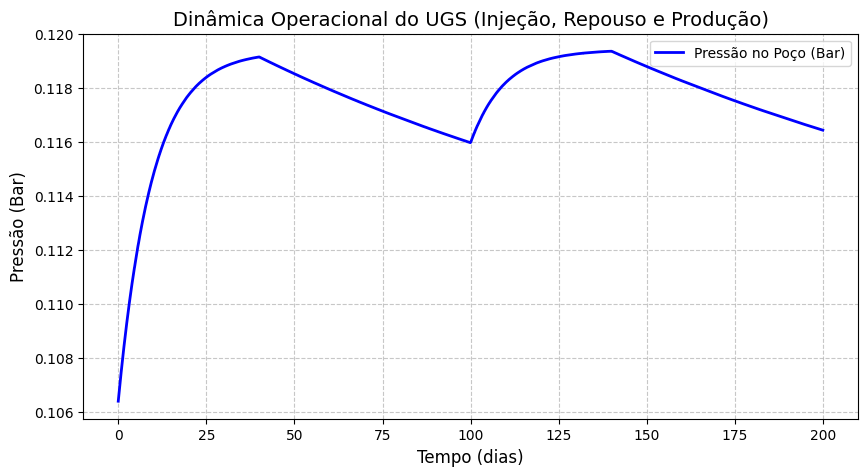

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

#Dados gerados pelo seu simulador
df_base = pd.read_csv('historico_base.csv')

#Tamanho e estilo do gráfico
plt.figure(figsize=(10, 5))

#Plotando a Pressão no Poço Injetor (convertendo Pascal para Bar dividindo por 1e5)
plt.plot(df_base['tempo'], df_base['pInjCell'] / 1e5, color='blue', linewidth=2, label='Pressão no Poço (Bar)')

#Ajustes visuais (Títulos e Eixos)
plt.title('Dinâmica Operacional do UGS (Injeção, Repouso e Produção)', fontsize=14)
plt.xlabel('Tempo (dias)', fontsize=12)
plt.ylabel('Pressão (Bar)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

#Exibindo o gráfico
plt.show()

Imagem guardada com sucesso: mapa_sg_base_50d.png


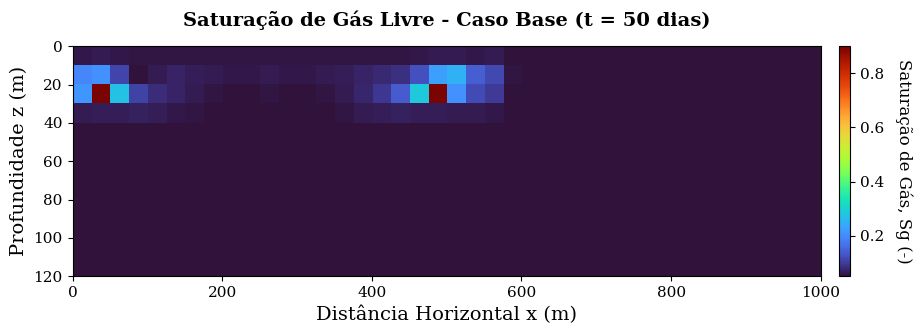

Imagem guardada com sucesso: mapa_c_base_50d.png


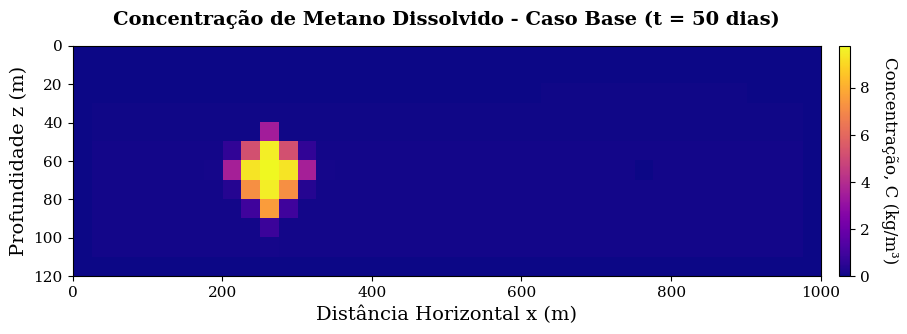

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#Formatação científica (Estilo Artigo/Tese)
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif', # Fonte LaTeX
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

def gerar_mapa_2d(ficheiro_csv, titulo, label_barra, nome_saida, mapa_cores='viridis'):
    """
    Lê o ficheiro CSV do simulador e gera um mapa de calor 2D.
    """
    try:
        # Matriz 2D gerada pelo C++ (separada por vírgulas)
        dados = np.loadtxt(ficheiro_csv, delimiter=',')
    except FileNotFoundError:
        print(f"Erro: O ficheiro '{ficheiro_csv}' não foi encontrado. Faz o upload no Colab.")
        return

    # Dimensões do domínio físico
    Lx = 1000.0  # metros
    Lz = 120.0   # metros

    # Figura com proporção retangular para refletir o aquífero real
    fig, ax = plt.subplots(figsize=(10, 3.5))

    # Plotar o heatmap
    # *extent inverte o eixo Z para a profundidade crescer para baixo
    im = ax.imshow(dados, cmap=mapa_cores, aspect='auto', extent=[0, Lx, Lz, 0])

    # Barra de cores
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(label_barra, rotation=270, labelpad=20, fontsize=12)

    # Eixos e título
    ax.set_title(titulo, pad=15, fontweight='bold')
    ax.set_xlabel('Distância Horizontal x (m)')
    ax.set_ylabel('Profundidade z (m)')

    # Ajustar o layout para não cortar os eixos e guardar a imagem
    plt.tight_layout()
    plt.savefig(nome_saida, dpi=300, bbox_inches='tight') # 300 DPI é exigência para teses
    print(f"Imagem guardada com sucesso: {nome_saida}")


    plt.show()


# EXECUÇÃO DA PLOTAGEM

# Gráfico 1: Saturação de Gás (A bolha de gás / Efeito da Gravidade)
# Destacar as frentes de saturação
gerar_mapa_2d(
    ficheiro_csv='base_campo_sg_t_50.csv',
    titulo='Saturação de Gás Livre - Caso Base (t = 50 dias)',
    label_barra='Saturação de Gás, Sg (-)',
    nome_saida='mapa_sg_base_50d.png',
    mapa_cores='turbo'
)

# Gráfico 2: Concentração de Metano (O teu diferencial IMPEC)
# O 'plasma' ou 'magma' ajuda a visualizar bem a difusão da pluma no aquífero
gerar_mapa_2d(
    ficheiro_csv='base_campo_c_t_50.csv',
    titulo='Concentração de Metano Dissolvido - Caso Base (t = 50 dias)',
    label_barra='Concentração, C (kg/m³)',
    nome_saida='mapa_c_base_50d.png',
    mapa_cores='plasma'
)

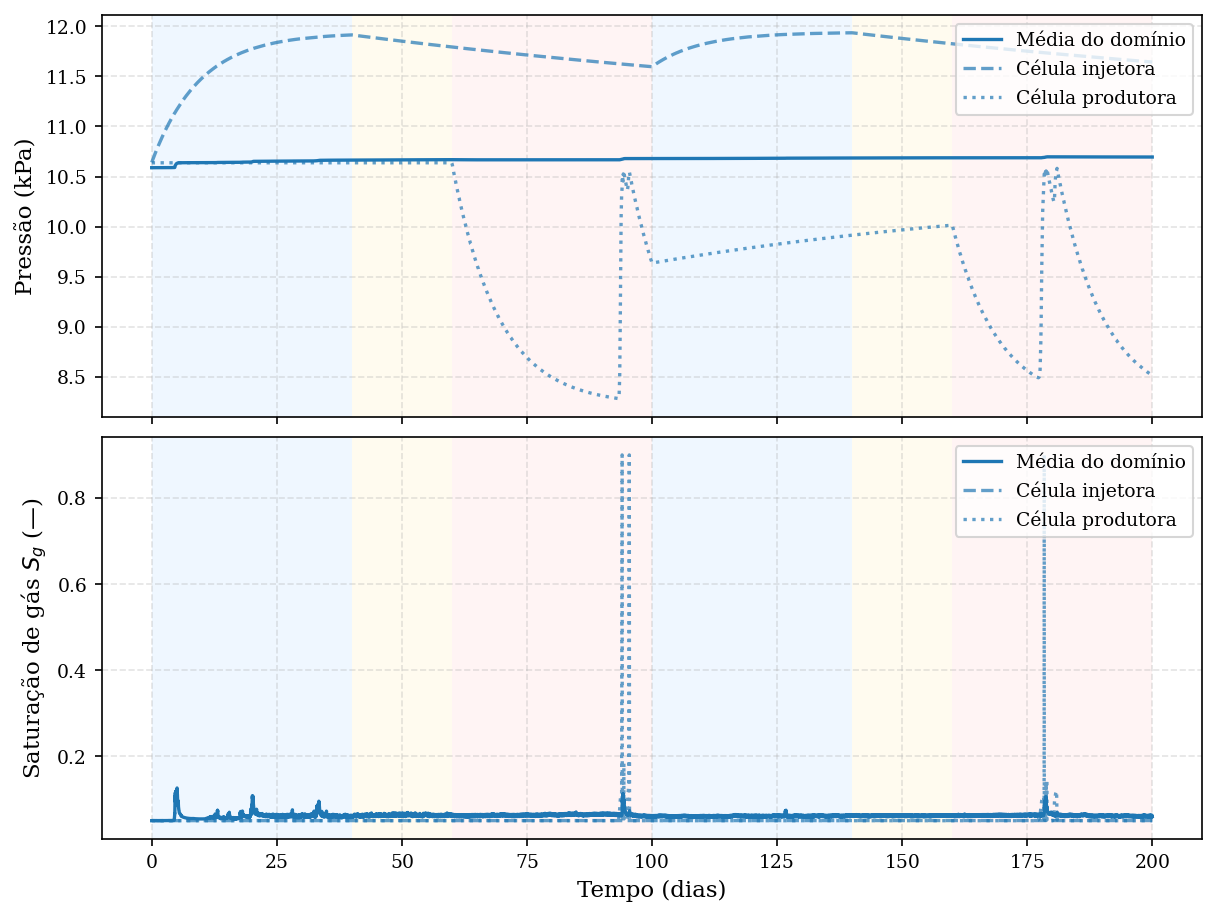

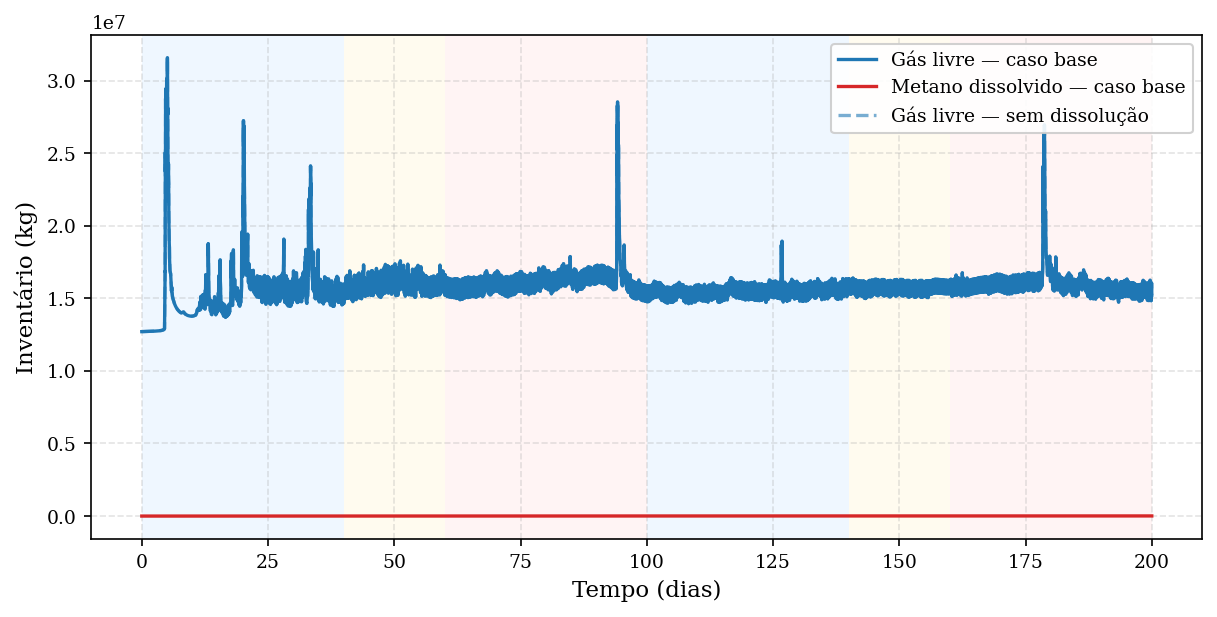

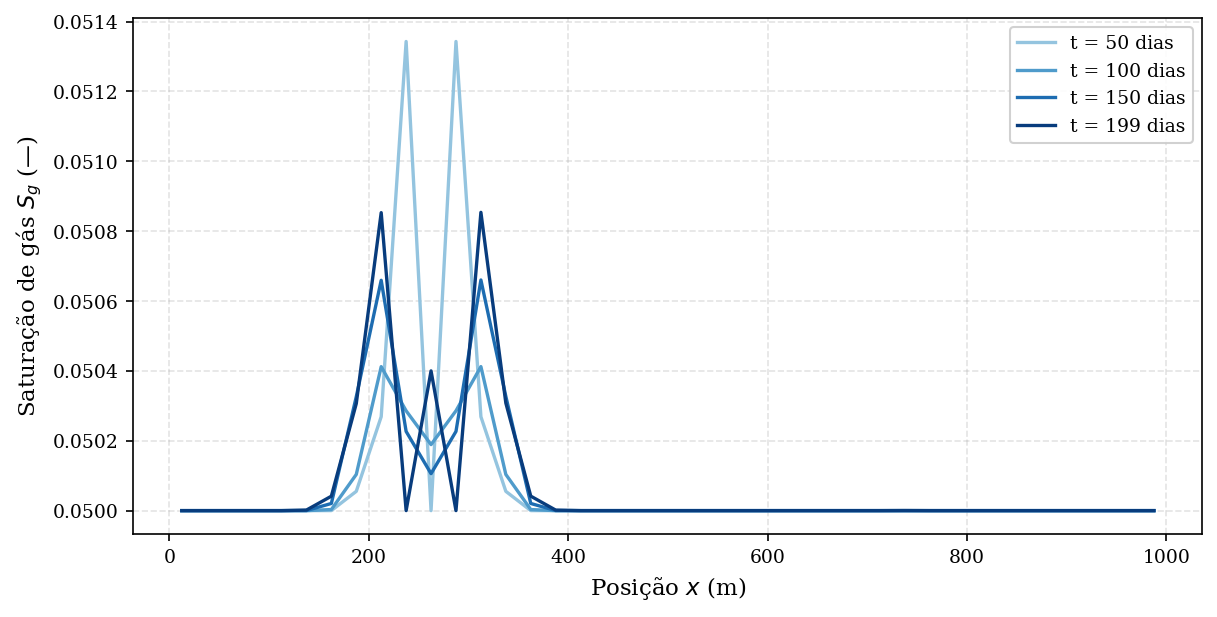

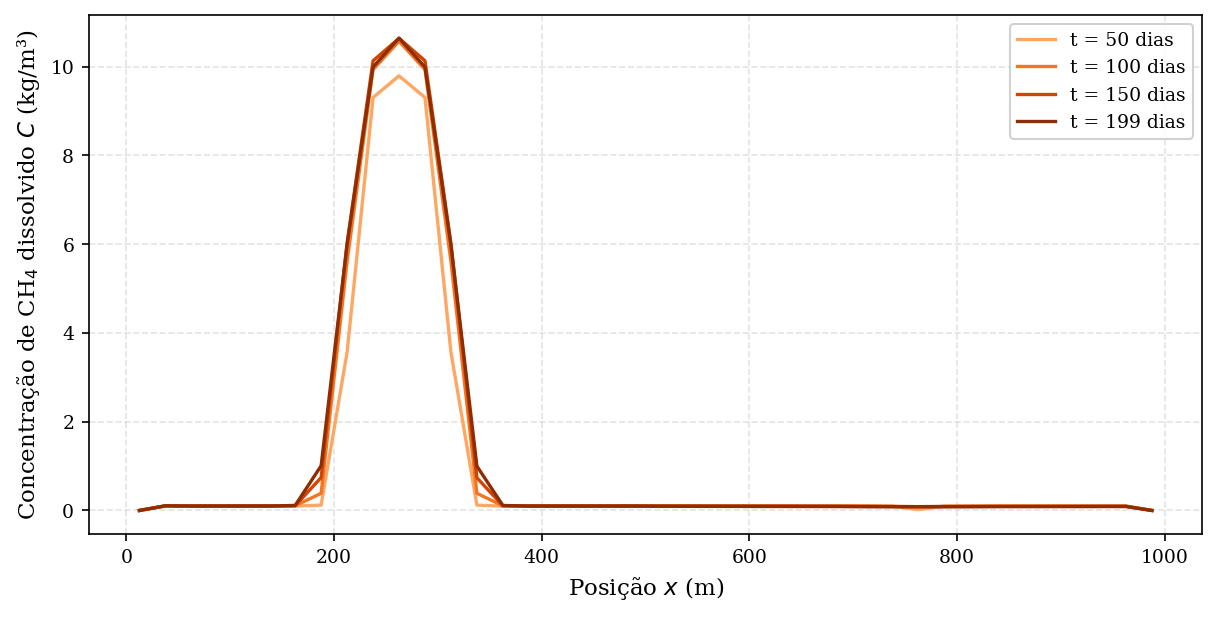

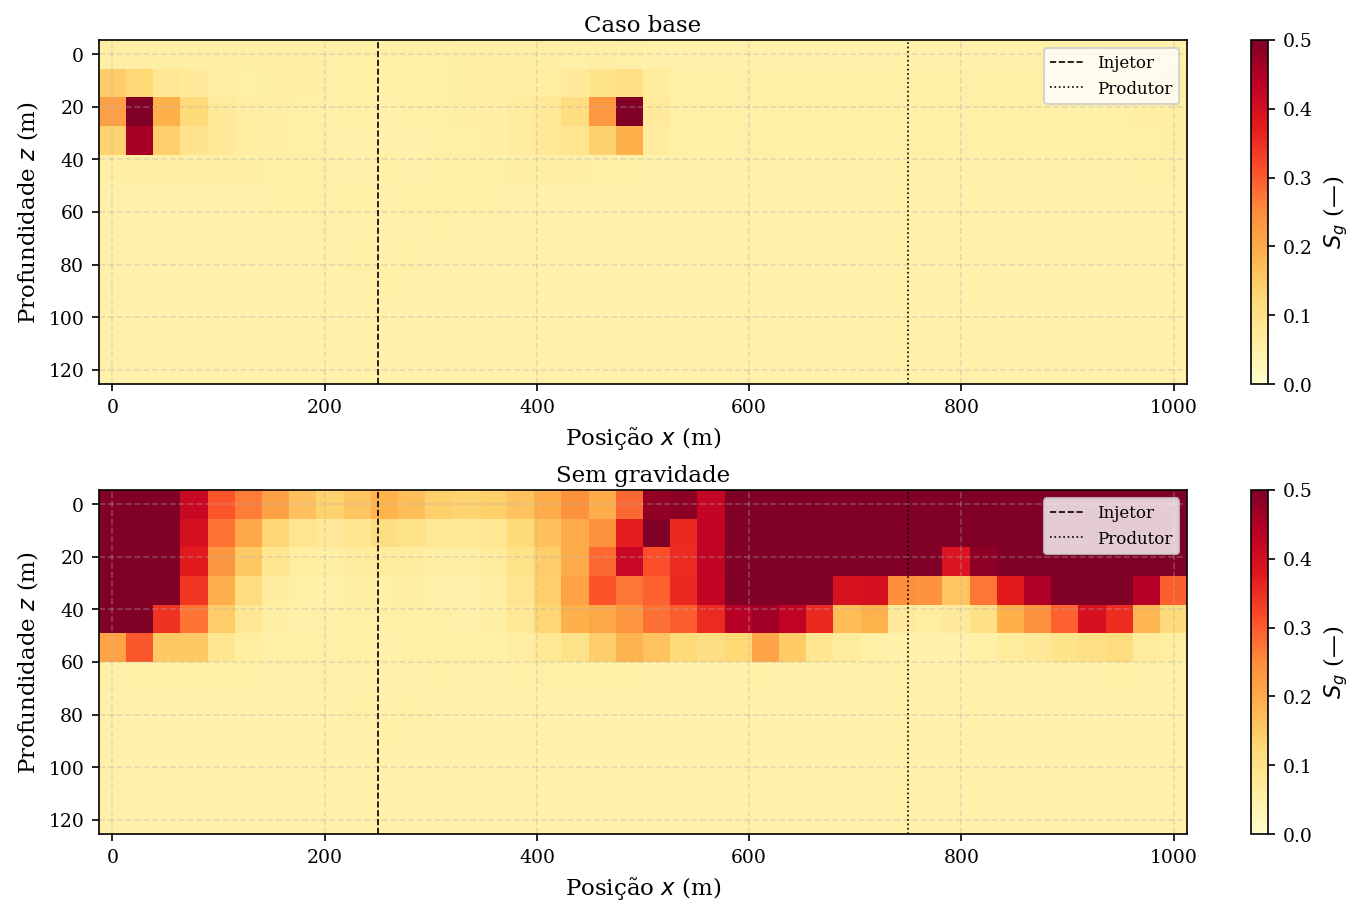

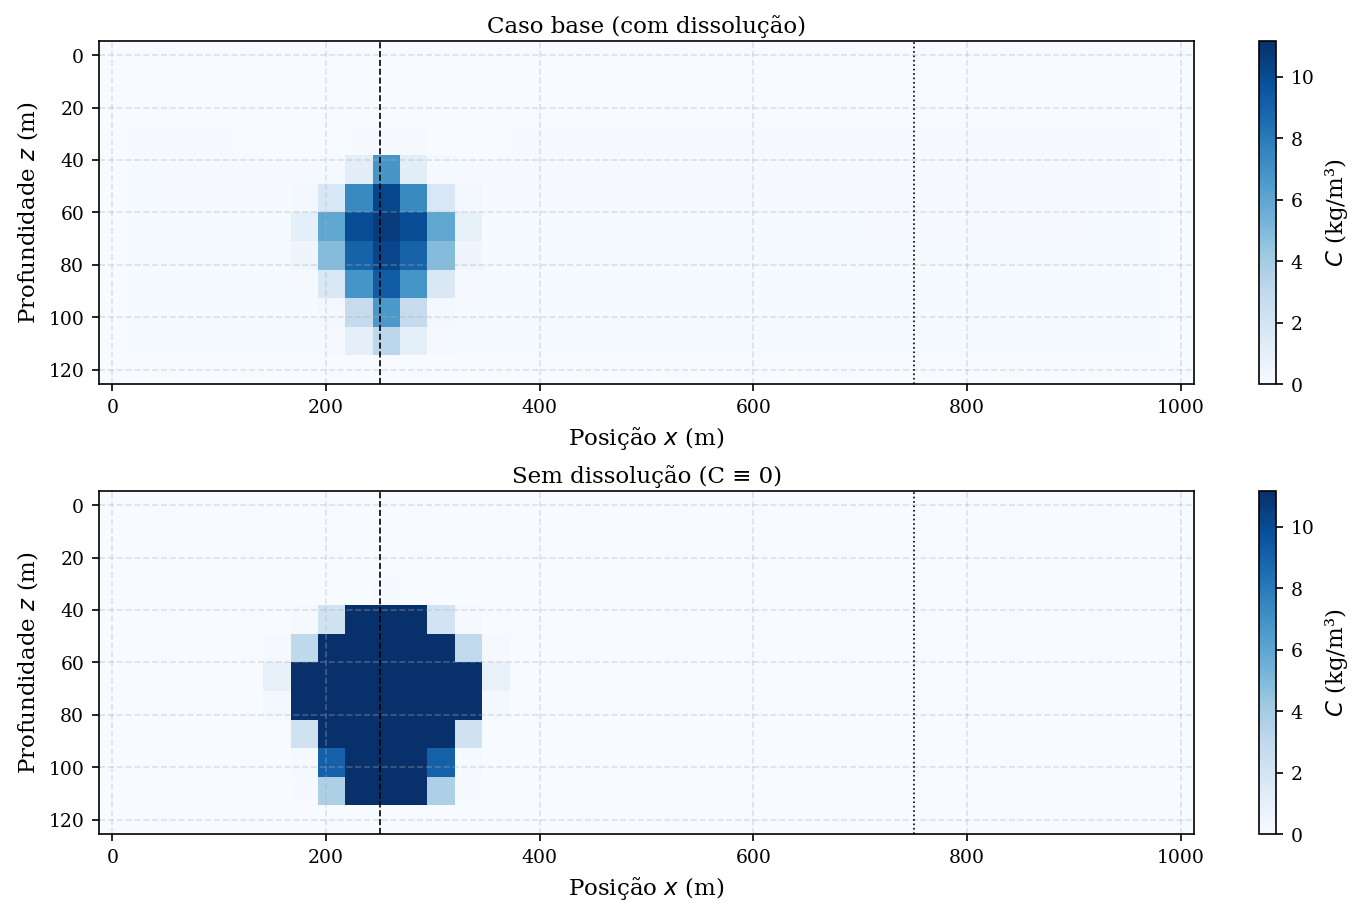

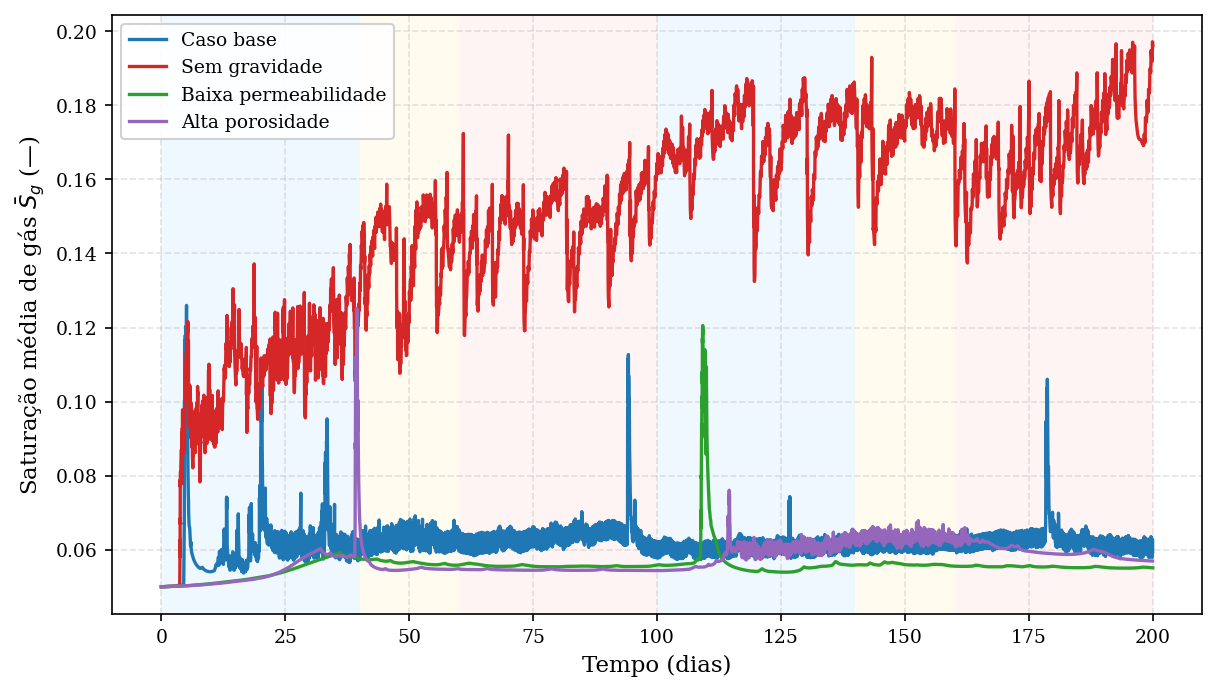

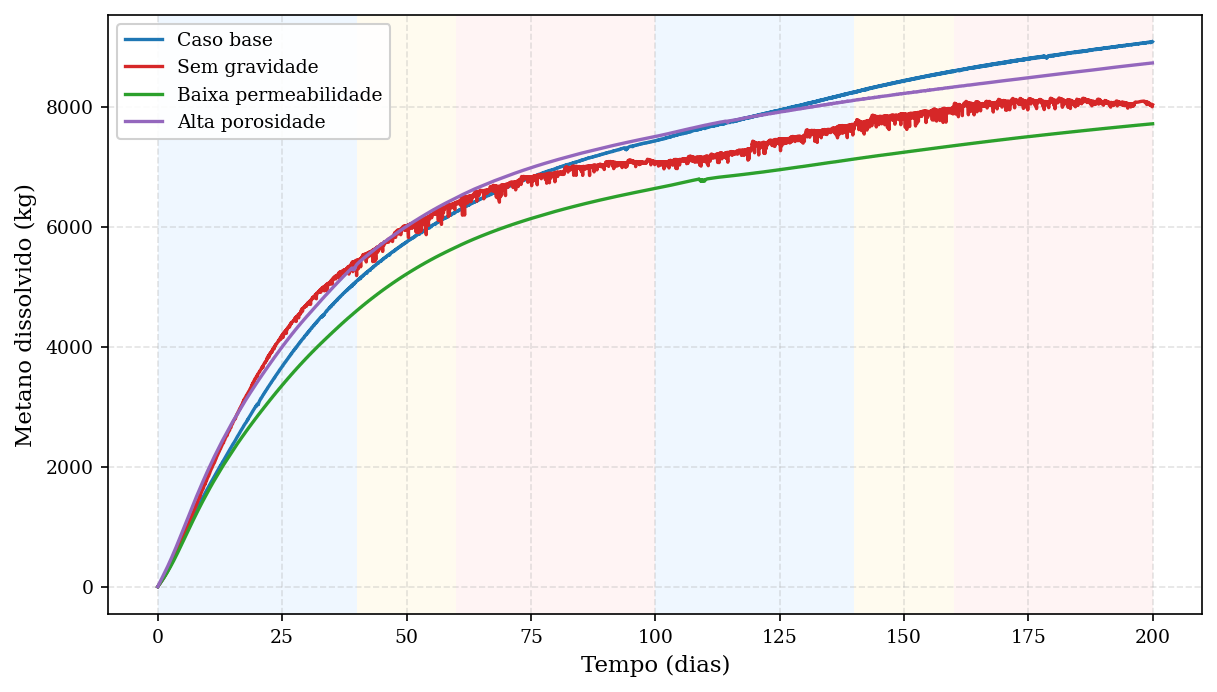

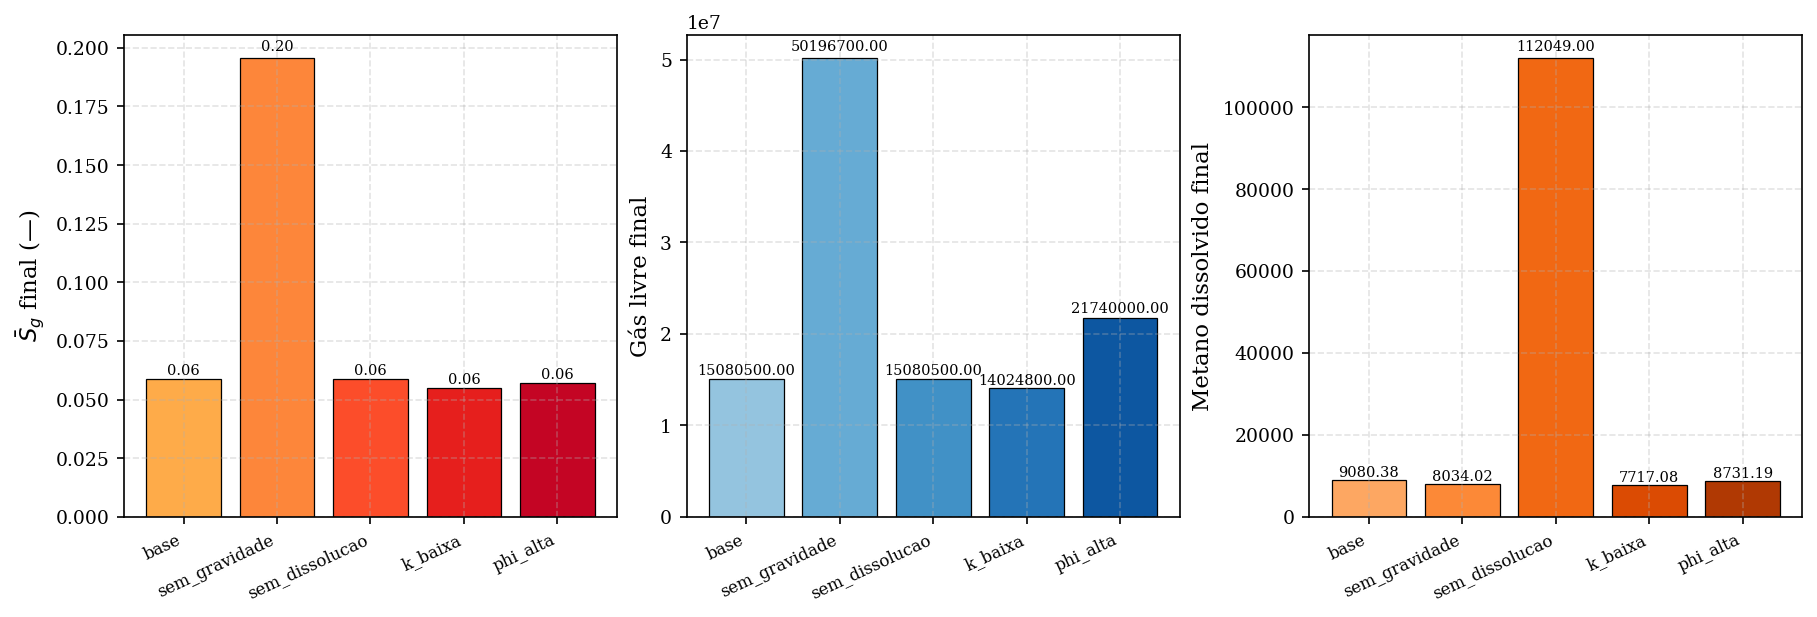


Baixando figuras automaticamente...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# ============================================================
# SIMULADOR UGS — GERAÇÃO DE GRÁFICOS PARA O CAPÍTULO 4
# ============================================================

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from google.colab import files
import os, glob

# Estilo global — Publicações ABNT
matplotlib.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.titlesize':    11,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
    'lines.linewidth':   1.6,
})

PASTA = '/content/'
os.makedirs(PASTA, exist_ok=True)

COR = {
    'base':           '#1f77b4',
    'sem_gravidade':  '#d62728',
    'sem_dissolucao': '#ff7f0e',
    'k_baixa':        '#2ca02c',
    'phi_alta':       '#9467bd',
}
LABEL = {
    'base':           'Caso base',
    'sem_gravidade':  'Sem gravidade',
    'sem_dissolucao': 'Sem dissolução',
    'k_baixa':        'Baixa permeabilidade',
    'phi_alta':       'Alta porosidade',
}
NX, NZ   = 40, 12
LX, LZ   = 1000.0, 120.0
TMAX     = 200.0
TINJ     = 40.0
TREPOUSO = 20.0
TPROD    = 40.0
PERIODO  = TINJ + TREPOUSO + TPROD

def carregar_historico(caso):
    path = os.path.join(PASTA, f'historico_{caso}.csv')
    return pd.read_csv(path)

def carregar_perfil(caso, t):
    path = os.path.join(PASTA, f'{caso}_perfil_t_{t}.csv')
    return pd.read_csv(path)

def carregar_campo2d(caso, variavel, t):
    path = os.path.join(PASTA, f'{caso}_campo_{variavel}_t_{t}.csv')
    return np.loadtxt(path, delimiter=',')

def adicionar_bandas_ciclo(ax, tmax, periodo, tinj, trepouso):
    t = 0.0
    while t < tmax:
        ax.axvspan(t, min(t + tinj, tmax), color='#cce5ff', alpha=0.30, lw=0)
        t += tinj
        ax.axvspan(t, min(t + trepouso, tmax), color='#fff3cd', alpha=0.30, lw=0)
        t += trepouso
        ax.axvspan(t, min(t + (periodo - tinj - trepouso), tmax), color='#ffd6d6', alpha=0.25, lw=0)
        t += (periodo - tinj - trepouso)

# FIGURA 1 - Evolução temporal: pressão e saturação (caso base)
def figura1_serie_temporal():
    df = carregar_historico('base')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, constrained_layout=True)
    # Bandas de ciclo
    for ax in (ax1, ax2): adicionar_bandas_ciclo(ax, TMAX, PERIODO, TINJ, TREPOUSO)
    # Pressão
    ax1.plot(df['tempo'], df['pMed']/1e3,      color=COR['base'],  label='Média do domínio')
    ax1.plot(df['tempo'], df['pInjCell']/1e3,  color='#1f77b4', ls='--', alpha=0.7, label='Célula injetora')
    ax1.plot(df['tempo'], df['pProdCell']/1e3, color='#1f77b4', ls=':',  alpha=0.7, label='Célula produtora')
    ax1.set_ylabel('Pressão (kPa)')
    ax1.legend(loc='upper right', framealpha=0.8)
    # Saturação de gás
    ax2.plot(df['tempo'], df['sgMed'],       color=COR['base'],  label='Média do domínio')
    ax2.plot(df['tempo'], df['SgInjCell'],   color='#1f77b4', ls='--', alpha=0.7, label='Célula injetora')
    ax2.plot(df['tempo'], df['SgProdCell'],  color='#1f77b4', ls=':',  alpha=0.7, label='Célula produtora')
    ax2.set_ylabel('Saturação de gás $S_g$ (—)')
    ax2.set_xlabel('Tempo (dias)')
    ax2.legend(loc='upper right', framealpha=0.8)
    fig.savefig('fig1_serie_temporal.png')
    plt.show()

# FIGURA 2 - Inventário de gás livre e metano dissolvido
def figura2_inventario():
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    adicionar_bandas_ciclo(ax, TMAX, PERIODO, TINJ, TREPOUSO)
    df_b, df_s = carregar_historico('base'), carregar_historico('sem_dissolucao')
    ax.plot(df_b['tempo'], df_b['massaLivre'], color='#1f77b4', label='Gás livre — caso base')
    ax.plot(df_b['tempo'], df_b['massaDissolvida'], color='#d62728', label='Metano dissolvido — caso base')
    ax.plot(df_s['tempo'], df_s['massaLivre'], color='#1f77b4', ls='--', alpha=0.6, label='Gás livre — sem dissolução')
    ax.set_xlabel('Tempo (dias)')
    ax.set_ylabel('Inventário (kg)')
    ax.legend(framealpha=0.9)
    fig.savefig('fig2_inventario.png')
    plt.show()

# FIGURA 3 - Perfis 1D de saturação ao longo de x (caso base)
def figura3_perfil_saturacao():
    tempos  = [50, 100, 150, 199]
    cores_t = plt.cm.Blues(np.linspace(0.4, 0.95, len(tempos)))
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    for t, cor in zip(tempos, cores_t):
        df = carregar_perfil('base', t)
        ax.plot(df['x'], df['Sg'], color=cor, label=f't = {t} dias')
    ax.set_xlabel('Posição $x$ (m)')
    ax.set_ylabel('Saturação de gás $S_g$ (—)')
    ax.legend(framealpha=0.9)
    fig.savefig('fig3_perfil_sg.png')
    plt.show()

# FIGURA 4 - Perfis 1D de concentração ao longo de x (caso base)
def figura4_perfil_concentracao():
    tempos  = [50, 100, 150, 199]
    cores_t = plt.cm.Oranges(np.linspace(0.4, 0.95, len(tempos)))
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    for t, cor in zip(tempos, cores_t):
        df = carregar_perfil('base', t)
        ax.plot(df['x'], df['C'], color=cor, label=f't = {t} dias')
    ax.set_xlabel('Posição $x$ (m)')
    ax.set_ylabel('Concentração de CH$_4$ dissolvido $C$ (kg/m³)')
    ax.legend(framealpha=0.9)
    fig.savefig('fig4_perfil_C.png')
    plt.show()

# FIGURA 5 - Campo 2D Sg: base vs sem_gravidade em t ~= 200
def figura5_campo2d_sg():
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), constrained_layout=True)
    X, Z = np.meshgrid(np.linspace(0, LX, NX), np.linspace(0, LZ, NZ))
    for ax, (caso, titulo) in zip(axes, [('base', 'Caso base'), ('sem_gravidade', 'Sem gravidade')]):
        arr = carregar_campo2d(caso, 'sg', 199)
        pcm = ax.pcolormesh(X, Z, arr, cmap='YlOrRd', vmin=0, vmax=0.5, shading='auto')
        fig.colorbar(pcm, ax=ax, label='$S_g$ (—)')
        ax.set_title(titulo, pad=4)
        ax.set_xlabel('Posição $x$ (m)')
        ax.set_ylabel('Profundidade $z$ (m)')
        # Poços
        ax.axvline(LX/4,   color='k', ls='--', lw=0.8, label='Injetor')
        ax.axvline(3*LX/4, color='k', ls=':',  lw=0.8, label='Produtor')
        ax.legend(loc='upper right', fontsize=8)
        ax.invert_yaxis()
    fig.savefig('fig5_campo_sg_comparativo.png')
    plt.show()

# FIGURA 6 - Campo 2D C: base vs sem_dissolucao em t ~= 200
def figura6_campo2d_C():
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), constrained_layout=True)
    X, Z = np.meshgrid(np.linspace(0, LX, NX), np.linspace(0, LZ, NZ))
    arr_b = carregar_campo2d('base', 'c', 199)
    vmax = arr_b.max() * 1.05 if arr_b.max() > 0 else 1.0
    for ax, (caso, titulo) in zip(axes, [('base', 'Caso base (com dissolução)'), ('sem_dissolucao', 'Sem dissolução (C ≡ 0)')]):
        arr = carregar_campo2d(caso, 'c', 199)
        pcm = ax.pcolormesh(X, Z, arr, cmap='Blues', vmin=0, vmax=vmax, shading='auto')
        fig.colorbar(pcm, ax=ax, label='$C$ (kg/m³)')
        ax.set_title(titulo, pad=4)
        ax.set_xlabel('Posição $x$ (m)')
        ax.set_ylabel('Profundidade $z$ (m)')
        ax.axvline(LX/4,   color='k', ls='--', lw=0.8)
        ax.axvline(3*LX/4, color='k', ls=':',  lw=0.8)
        ax.invert_yaxis()
    fig.savefig('fig6_campo_C_comparativo.png')
    plt.show()

# FIGURA 7 - Comparativo SgMed: efeito da gravidade e permeabilidade
def figura7_comparativo_sg():
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    adicionar_bandas_ciclo(ax, TMAX, PERIODO, TINJ, TREPOUSO)
    for caso in ['base', 'sem_gravidade', 'k_baixa', 'phi_alta']:
        df = carregar_historico(caso)
        ax.plot(df['tempo'], df['sgMed'], color=COR[caso], label=LABEL[caso])
    ax.set_xlabel('Tempo (dias)')
    ax.set_ylabel('Saturação média de gás $\\bar{S}_g$ (—)')
    ax.legend(framealpha=0.9)
    fig.savefig('fig7_comparativo_sg.png')
    plt.show()

# FIGURA 8 - Comparativo inventário dissolvido
def figura8_comparativo_dissolvido():
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    adicionar_bandas_ciclo(ax, TMAX, PERIODO, TINJ, TREPOUSO)
    for caso in ['base', 'sem_gravidade', 'k_baixa', 'phi_alta']:
        df = carregar_historico(caso)
        ax.plot(df['tempo'], df['massaDissolvida'], color=COR[caso], label=LABEL[caso])
    ax.set_xlabel('Tempo (dias)')
    ax.set_ylabel('Metano dissolvido (kg)')
    ax.legend(framealpha=0.9)
    fig.savefig('fig8_comparativo_dissolvido.png')
    plt.show()

# FIGURA 9 - Comparativo tabela final (resumo_casos.csv)
def figura9_tabela_resumo():
    df = pd.read_csv(os.path.join(PASTA, 'resumo_casos.csv'))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    metricas = [('sgMed', '$\\bar{S}_g$ final (—)', 'YlOrRd'), ('massaLivre', 'Gás livre final', 'Blues'), ('massaDissolvida', 'Metano dissolvido final', 'Oranges')]
    for ax, (col, ylabel, cmap) in zip(axes, metricas):
        cores = plt.get_cmap(cmap)(np.linspace(0.4, 0.85, len(df)))
        barras = ax.bar(df['caso'], df[col], color=cores, edgecolor='k', lw=0.6)
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(df['caso'])))
        ax.set_xticklabels(df['caso'], rotation=25, ha='right', fontsize=8)
        for b in barras:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h * 1.01, f'{h:.2f}', ha='center', va='bottom', fontsize=7)
    fig.savefig('fig9_resumo_casos.png')
    plt.show()

# EXECUTAR TODAS
figura1_serie_temporal()
figura2_inventario()
figura3_perfil_saturacao()
figura4_perfil_concentracao()
figura5_campo2d_sg()
figura6_campo2d_C()
figura7_comparativo_sg()
figura8_comparativo_dissolvido()
figura9_tabela_resumo()

print('\nBaixando figuras automaticamente...')
for f in sorted(glob.glob('fig*.png')):
    files.download(f)